
=== MODELLERİN PERFORMANS TABLOSU ===
                     Accuracy    Recall  Precision        F1     Kappa  \
Logistic Regression  0.816279  0.743421   0.738562  0.740984  0.598644   
SVM                  0.869767  0.789474   0.833333  0.810811  0.711631   
KNN                  0.830233  0.756579   0.761589  0.759076  0.628019   
Decision Tree        0.953488  0.960526   0.912500  0.935897  0.899439   
Random Forest        0.955814  0.934211   0.940397  0.937294  0.903183   
AdaBoost             0.925581  0.894737   0.894737  0.894737  0.837183   
Gradient Boosting    0.955814  0.947368   0.929032  0.938111  0.903758   
MLP (ANN)            0.879070  0.842105   0.820513  0.831169  0.736991   

                          AUC  
Logistic Regression  0.889814  
SVM                  0.939654  
KNN                  0.903469  
Decision Tree        0.955083  
Random Forest        0.988191  
AdaBoost             0.946150  
Gradient Boosting    0.983067  
MLP (ANN)            0.950043  

=== K

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


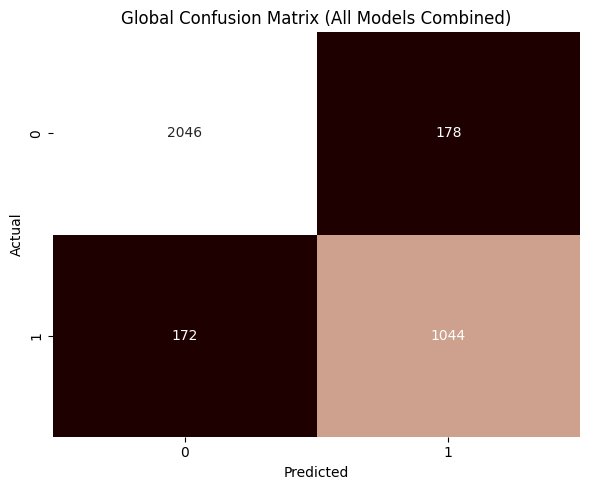

In [ ]:
# ===============================
# 1. KÜTÜPHANELER
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, kruskal

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score, roc_auc_score,
    confusion_matrix, cohen_kappa_score, roc_curve
)

# ===============================
# 2. VERİ YÜKLEME
# ===============================
df = pd.read_csv("/content/alzheimers_disease_data.csv")

# ===============================
# 3. HEDEF VE ÖZELLİKLER
# ===============================
TARGET = "Diagnosis"
X = df.drop(TARGET, axis=1)
y = df[TARGET]

# Gereksiz sütun
if "DoctorInCharge" in X.columns:
    X = X.drop("DoctorInCharge", axis=1)

# ===============================
# 4. ÖLÇEKLEME
# ===============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ===============================
# 5. ÖZELLİK SEÇİMİ
# ===============================
selector = SelectKBest(score_func=f_classif, k=10)
X_selected = selector.fit_transform(X_scaled, y)

# ===============================
# 6. TRAIN–TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, stratify=y, random_state=42
)

# ===============================
# 7. MODELLER
# ===============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "MLP (ANN)": MLPClassifier(max_iter=500, random_state=42)
}

# ===============================
# 8. MODEL EĞİTİMİ & METRİKLER
# ===============================
results = {}
accuracy_list = []  # Kruskal için Accuracy değerleri
f1_list = []        # Kruskal için F1 değerleri
auc_list = []       # Kruskal için AUC değerleri
model_names = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results[name] = {
        "Accuracy": acc,
        "Recall": recall_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "F1": f1,
        "Kappa": cohen_kappa_score(y_test, y_pred),
        "AUC": auc
    }

    # Kruskal için değerleri ekle
    accuracy_list.append(acc)
    f1_list.append(f1)
    auc_list.append(auc)
    model_names.append(name)

results_df = pd.DataFrame(results).T
print("\n=== MODELLERİN PERFORMANS TABLOSU ===")
print(results_df)

# ===============================
# 9. KRUSKAL-WALLIS TESTİ
# ===============================
# H0: Tüm modellerin Accuracy ortalamaları aynı
# H1: En az bir model farklı

stat_acc, p_acc = kruskal(*[ [results[name]["Accuracy"]] for name in model_names ])
stat_f1, p_f1 = kruskal(*[ [results[name]["F1"]] for name in model_names ])
stat_auc, p_auc = kruskal(*[ [results[name]["AUC"]] for name in model_names ])

print("\n=== KRUSKAL-WALLIS TESTİ SONUÇLARI ===")
print(f"Accuracy: stat={stat_acc:.3f}, p-value={p_acc:.3f}")
print(f"F1-score: stat={stat_f1:.3f}, p-value={p_f1:.3f}")
print(f"AUC: stat={stat_auc:.3f}, p-value={p_auc:.3f}")

# ===============================
# 10. TÜM ALGORİTMALAR İÇİN TEK CONFUSION MATRIX
# ===============================
all_preds = []
all_true = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    all_preds.extend(y_pred)
    all_true.extend(y_test)

global_cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(global_cm, annot=True, fmt="d", cmap="pink", cbar=False)
plt.title("Global Confusion Matrix (All Models Combined)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


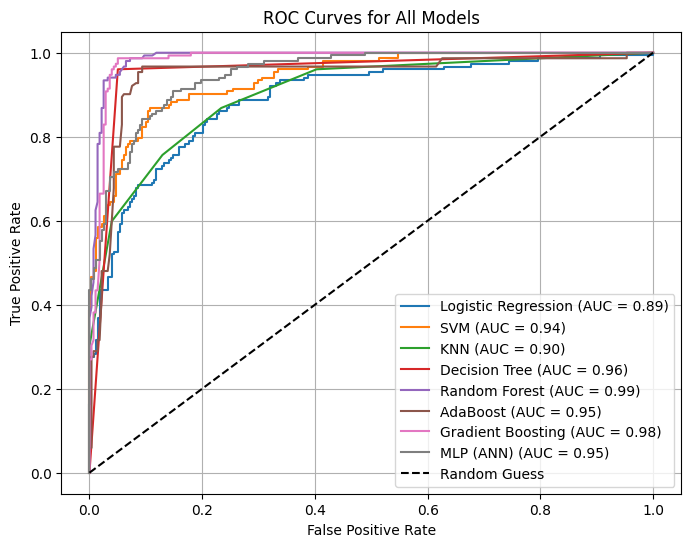

In [ ]:
# ===============================
# 11. TÜM MODELLERİN ROC EĞRİSİ
# ===============================
plt.figure(figsize=(8, 6))

for name, model in models.items():
    # model.predict_proba ile pozitif sınıf olasılıklarını al
    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

# Rastgele tahmin çizgisi
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


Processing: Logistic Regression
Processing: SVM
Processing: KNN
Processing: Decision Tree
Processing: Random Forest
Processing: AdaBoost
Processing: Gradient Boosting
Processing: MLP (ANN)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro


=== MODELLERİN PERFORMANS TABLOSU (5-Fold CV) ===
                     Accuracy    Recall  Precision        F1     Kappa  \
Logistic Regression  0.844579  0.742105   0.803419  0.771546  0.654055   
SVM                  0.878548  0.786842   0.857963  0.820865  0.729255   
KNN                  0.857143  0.778947   0.809850  0.794098  0.684792   
Decision Tree        0.949279  0.925000   0.931126  0.928053  0.888887   
Random Forest        0.952536  0.923684   0.941019  0.932271  0.895743   
AdaBoost             0.933923  0.914474   0.900259  0.907311  0.855978   
Gradient Boosting    0.954863  0.943421   0.929961  0.936643  0.901590   
MLP (ANN)            0.897627  0.840789   0.865854  0.853138  0.774592   

                          AUC  
Logistic Regression  0.902821  
SVM                  0.943633  
KNN                  0.911757  
Decision Tree        0.943781  
Random Forest        0.989652  
AdaBoost             0.955235  
Gradient Boosting    0.982729  
MLP (ANN)            0.958

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


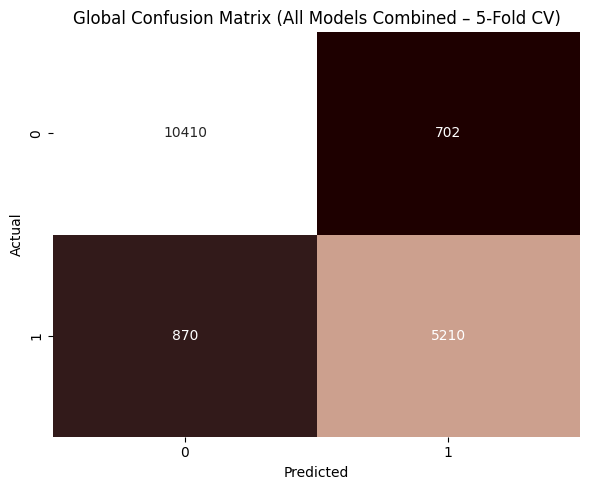

In [ ]:
# ===============================
# 1. KÜTÜPHANELER
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix, cohen_kappa_score, roc_curve
)

# ===============================
# 2. VERİ YÜKLEME
# ===============================
df = pd.read_csv("/content/alzheimers_disease_data.csv")

TARGET = "Diagnosis"
X = df.drop(TARGET, axis=1)
y = df[TARGET]

if "DoctorInCharge" in X.columns:
    X = X.drop("DoctorInCharge", axis=1)

# ===============================
# 3. ÖLÇEKLEME & ÖZELLİK SEÇİMİ
# ===============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

selector = SelectKBest(score_func=f_classif, k=10)
X_selected = selector.fit_transform(X_scaled, y)

# ===============================
# 4. MODELLER
# ===============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "MLP (ANN)": MLPClassifier(max_iter=500, random_state=42)
}

# ===============================
# 5. STRATIFIED K-FOLD CROSS VALIDATION
# ===============================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
global_true = []
global_pred = []

for name, model in models.items():
    print(f"Processing: {name}")

    # Cross-validated predictions
    y_pred_cv = cross_val_predict(model, X_selected, y, cv=cv, method="predict")

    if hasattr(model, "predict_proba"):
        y_prob_cv = cross_val_predict(model, X_selected, y, cv=cv, method="predict_proba")[:,1]
        auc = roc_auc_score(y, y_prob_cv)
    else:
        auc = np.nan

    # Metrics
    acc = accuracy_score(y, y_pred_cv)
    rec = recall_score(y, y_pred_cv)
    prec = precision_score(y, y_pred_cv)
    f1 = f1_score(y, y_pred_cv)
    kappa = cohen_kappa_score(y, y_pred_cv)

    results[name] = {
        "Accuracy": acc,
        "Recall": rec,
        "Precision": prec,
        "F1": f1,
        "Kappa": kappa,
        "AUC": auc
    }

    # Global confusion matrix için
    global_true.extend(y)
    global_pred.extend(y_pred_cv)

# Results Table
results_df = pd.DataFrame(results).T
print("\n=== MODELLERİN PERFORMANS TABLOSU (5-Fold CV) ===")
print(results_df)

# ===============================
# 6. KRUSKAL-WALLIS TESTİ
# ===============================
stat_acc, p_acc = kruskal(*[[results[name]["Accuracy"]] for name in results])
stat_f1, p_f1 = kruskal(*[[results[name]["F1"]] for name in results])
stat_auc, p_auc = kruskal(*[[results[name]["AUC"]] for name in results if not np.isnan(results[name]["AUC"])])

print("\n=== KRUSKAL-WALLIS TESTİ SONUÇLARI ===")
print(f"Accuracy: stat={stat_acc:.3f}, p-value={p_acc:.3f}")
print(f"F1-score: stat={stat_f1:.3f}, p-value={p_f1:.3f}")
print(f"AUC: stat={stat_auc:.3f}, p-value={p_auc:.3f}")

# ===============================
# 7. GLOBAL CONFUSION MATRIX (Tüm Algoritmalar)
# ===============================
global_cm = confusion_matrix(global_true, global_pred)

plt.figure(figsize=(6,5))
sns.heatmap(global_cm, annot=True, fmt="d", cmap="pink", cbar=False)
plt.title("Global Confusion Matrix (All Models Combined – 5-Fold CV)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

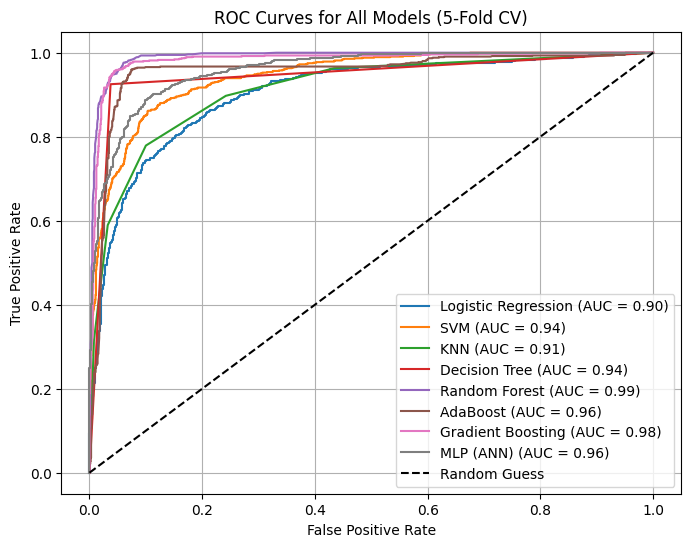

In [ ]:
# ===============================
# 8. TÜM MODELLERİN ROC EĞRİSİ (5-Fold CV)
# ===============================
plt.figure(figsize=(8, 6))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        # CV tahminleri için cross_val_predict kullanıyoruz
        y_prob_cv = cross_val_predict(model, X_selected, y, cv=cv, method="predict_proba")[:, 1]
        fpr, tpr, _ = roc_curve(y, y_prob_cv)
        auc = roc_auc_score(y, y_prob_cv)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

# Rastgele tahmin çizgisi
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models (5-Fold CV)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
